# Meridional wind at FL430 (162.4 hPa), January 2015–2025

How often is the flow at release height equatorward? Maps of the mean meridional wind, its day-to-day
variability, the fraction of days with v ≤ 0 (poleward or zero in the SH), and the temporal
autocorrelation timescale of daily-mean v.

Source: ERA5 via the public ARCO-ERA5 zarr on Google Cloud. u and v at 150 and 175 hPa are interpolated
in ln p to 162.4 hPa and stored 6-hourly per year (stage 1, resumable). Daily means are formed in stage 2.
Needs `gcsfs` and `zarr`.

In [1]:
import glob
import os
import time

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

# ---- configuration ----
ARCO_ERA5 = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
YEARS = (2015, 2025)               # inclusive
MONTH = 1                          # January
LAT_MAX = -30.0
HOURS = [0, 6, 12, 18]
P_FL430 = 226.32 * np.exp(-9.80665 * (43000 * 0.3048 - 11000.0) / (287.05287 * 216.65))   # 162.4 hPa
WIND_DIR = "winds_fl430"           # stage-1 output, one file per year
FIG_FILE = f"v_fl430_Jan_{YEARS[0]}-{YEARS[1]}.pdf"
os.makedirs(WIND_DIR, exist_ok=True)
print(f"FL430 = {P_FL430:.2f} hPa")

FL430 = 162.36 hPa


## Stage 1: extract u and v at FL430 from ARCO-ERA5

Reads `u_component_of_wind` and `v_component_of_wind` at 150 and 175 hPa for every January day at
`HOURS`, selects the 1° grid points (lat ≤ −30°, lon −180…179), interpolates in ln p to 162.4 hPa, and
writes one file per year. Not yet verified against the live store: variable names, coordinate names and how
far the store extends in time. The cell prints the store's time range; a January beyond the end is skipped.

In [2]:
def wind_path(y):
    return os.path.join(WIND_DIR, f"uv_fl430_{y}.nc")


need = [y for y in range(YEARS[0], YEARS[1] + 1) if not os.path.exists(wind_path(y))]
print("years to fetch:", need)

if need:
    era = xr.open_zarr(ARCO_ERA5, chunks=None, storage_options=dict(token="anon"))
    print("time range:", str(era.time.values[0])[:10], "..", str(era.time.values[-1])[:10])
    lat_j = np.arange(-90.0, LAT_MAX + 0.5, 1.0)
    lon_j = np.arange(-180.0, 180.0, 1.0)
    lon_e = lon_j % 360.0                              # ARCO longitudes run 0..359.75
    w175 = (np.log(P_FL430) - np.log(150.0)) / (np.log(175.0) - np.log(150.0))
    for y in need:
        days = pd.date_range(f"{y}-{MONTH:02d}-01", periods=31, freq="D")
        times = np.array([np.datetime64(d.replace(hour=h)) for d in days for h in HOURS])
        if times[-1] > era.time.values[-1]:
            print(f"  {y}: beyond end of store, skipped")
            continue
        t0 = time.time()
        sub = (era[["u_component_of_wind", "v_component_of_wind"]]
               .sel(time=times, level=[150, 175])
               .sel(latitude=lat_j, longitude=lon_e, method="nearest").load())
        sub = sub.assign_coords(longitude=lon_j).rename(latitude="lat", longitude="lon")
        out = xr.Dataset()
        for src, name in [("u_component_of_wind", "u"), ("v_component_of_wind", "v")]:
            f = (1 - w175) * sub[src].sel(level=150) + w175 * sub[src].sel(level=175)
            out[name] = f.drop_vars("level", errors="ignore").astype("f4")
            out[name].attrs = dict(units="m s-1", long_name=f"{name} at {P_FL430:.1f} hPa (FL430), ln-p interpolated 150/175 hPa")
        out.attrs = dict(source=ARCO_ERA5, hours=str(HOURS))
        out.to_netcdf(wind_path(y))
        print(f"  {y}: {out.sizes['time']} steps, v range {float(out.v.min()):.1f}..{float(out.v.max()):.1f} m/s, "
              f"{time.time() - t0:.0f} s")

uv = xr.concat([xr.load_dataset(f) for f in sorted(glob.glob(os.path.join(WIND_DIR, "*.nc")))], "time").sortby("time")
print(uv.sizes, "years:", sorted(set(uv.time.dt.year.values)))

years to fetch: []


Frozen({'time': 1364, 'lat': 61, 'lon': 360}) years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Stage 2: daily means and statistics

- daily-mean u and v from the 6-hourly values
- mean and standard deviation of daily v over all January days
- fraction of days with v ≤ 0 (poleward or zero)
- lag-1 autocorrelation r₁ of daily-v anomalies (grid-point January mean removed), using consecutive-day
  pairs within each January, pooled over years; e-folding timescale τ = −1/ln r₁ (NaN where r₁ ≤ 0)
- the same r₁ and τ from zonally pooled pairs by latitude, which is much less noisy than the gridded version

In [3]:
daily = uv.resample(time="1D").mean()
daily = daily.sel(time=daily.time.dt.month == MONTH)
v, u = daily.v, daily.u
years = sorted(set(v.time.dt.year.values))
print(f"{v.sizes['time']} January days over {len(years)} years")

v_mean = v.mean("time")
v_std = v.std("time", ddof=1)
frac_poleward = (v <= 0).mean("time")
u_mean = u.mean("time")

# lag-1 autocorrelation from within-year consecutive-day pairs
a = v - v_mean
num = xr.zeros_like(v_mean)
den = xr.zeros_like(v_mean)
num_z = np.zeros(v.sizes["lat"])
den_z = np.zeros(v.sizes["lat"])
for y in years:
    ay = a.sel(time=str(y)).values                       # (nday, nlat, nlon)
    p = (ay[:-1] * ay[1:]).sum(0)
    q = (ay ** 2).sum(0)
    num += p
    den += q
    num_z += p.sum(-1)
    den_z += q.sum(-1)
r1 = num / den
tau = -1.0 / np.log(r1.where(r1 > 0))
r1_z = num_z / den_z
tau_z = np.where(r1_z > 0, -1.0 / np.log(np.where(r1_z > 0, r1_z, np.nan)), np.nan)

stats = xr.Dataset(dict(v_mean=v_mean, v_std=v_std, frac_poleward=frac_poleward, u_mean=u_mean, r1=r1, tau=tau,
                        r1_zonal=("lat", r1_z), tau_zonal=("lat", tau_z)))
stats.attrs = dict(years=f"{years[0]}-{years[-1]}", month=MONTH, p_hPa=float(P_FL430), hours=str(HOURS))
stats.to_netcdf(f"v_fl430_stats_Jan_{years[0]}-{years[-1]}.nc")

print("zonal means by latitude band:")
for lo, hi in [(-40, -30), (-50, -40), (-60, -50), (-70, -60), (-80, -70), (-90, -80)]:
    s = stats.sel(lat=slice(lo, hi - 1e-6))
    print(f"  {-hi:2d}-{-lo:2d}S: v_mean {float(s.v_mean.mean()):+.2f} m/s, v_std {float(s.v_std.mean()):.2f}, "
          f"P(v<=0) {float(s.frac_poleward.mean()):.2f}, tau(zonal) {float(np.nanmean(s.tau_zonal)):.1f} d, "
          f"u_mean {float(s.u_mean.mean()):+.1f} m/s")

341 January days over 11 years


zonal means by latitude band:
  30-40S: v_mean +0.25 m/s, v_std 11.14, P(v<=0) 0.49, tau(zonal) 2.0 d, u_mean +23.7 m/s
  40-50S: v_mean +0.50 m/s, v_std 12.06, P(v<=0) 0.48, tau(zonal) 1.2 d, u_mean +27.7 m/s
  50-60S: v_mean +0.25 m/s, v_std 10.98, P(v<=0) 0.50, tau(zonal) 1.6 d, u_mean +22.3 m/s
  60-70S: v_mean +0.01 m/s, v_std 7.54, P(v<=0) 0.53, tau(zonal) 2.4 d, u_mean +10.6 m/s
  70-80S: v_mean -0.06 m/s, v_std 5.32, P(v<=0) 0.53, tau(zonal) 4.1 d, u_mean +4.1 m/s
  80-90S: v_mean -0.04 m/s, v_std 4.35, P(v<=0) 0.51, tau(zonal) 5.7 d, u_mean +1.3 m/s


## Maps

South polar view, 30–90°S. Top row: mean v, standard deviation of daily v, fraction of days with v ≤ 0.
Bottom row: r₁, τ (gridded), mean u. Latitude circles at 45, 60 and 75°S.

wrote v_fl430_Jan_2015-2025.pdf


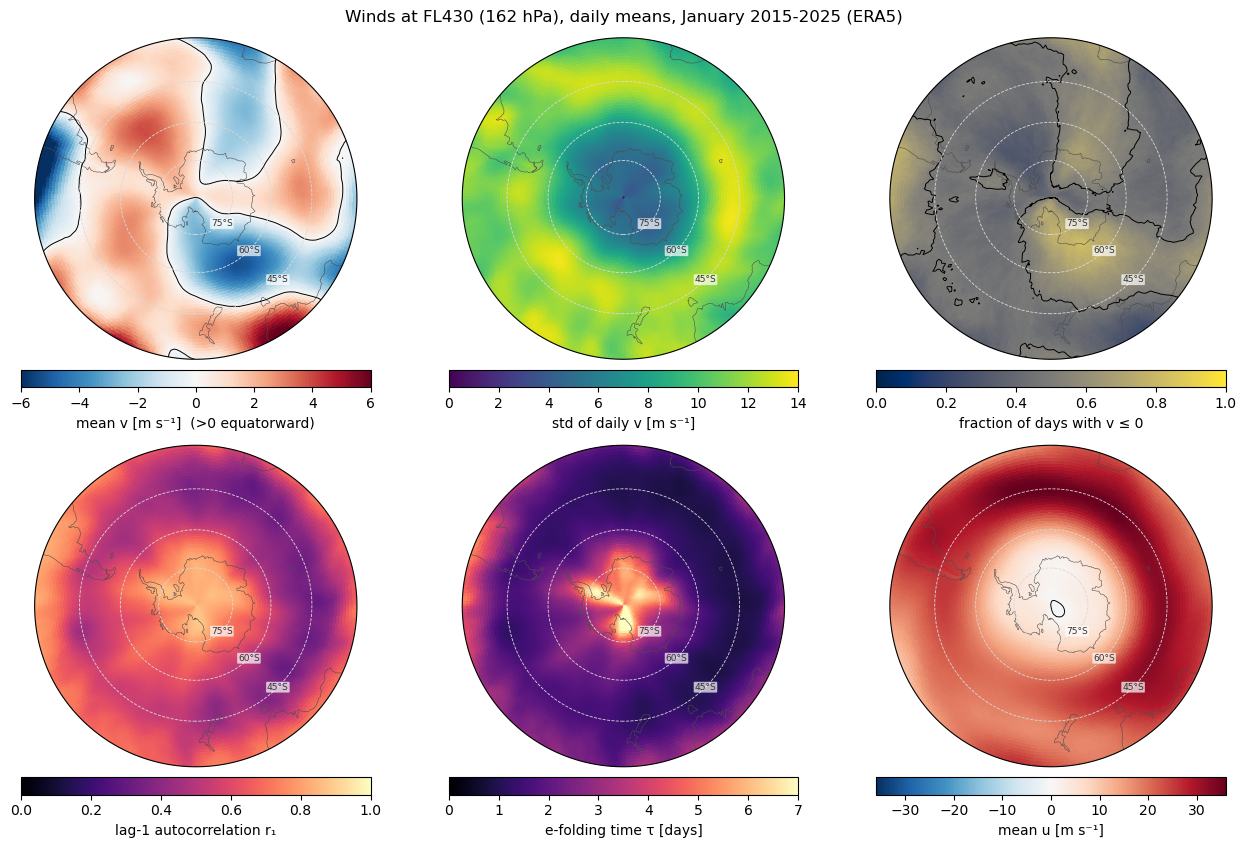

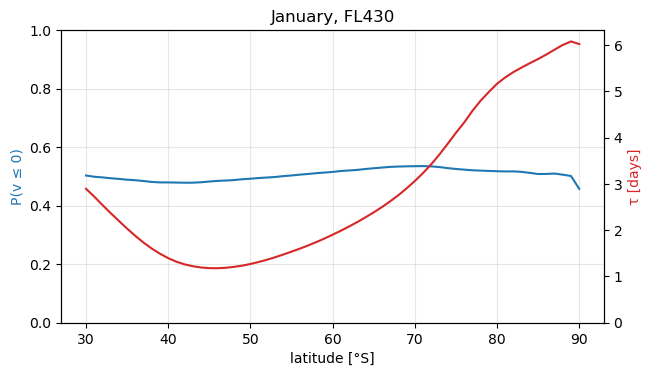

In [4]:
lat, lon = stats.lat.values, stats.lon.values
theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5)
pc = ccrs.PlateCarree()
lon_line = np.linspace(-180, 180, 361)

vlim = float(np.ceil(abs(stats.v_mean).quantile(0.99)))
panels = [("v_mean", "mean v [m s⁻¹]  (>0 equatorward)", "RdBu_r", -vlim, vlim),
          ("v_std", "std of daily v [m s⁻¹]", "viridis", 0, float(np.ceil(stats.v_std.quantile(0.99)))),
          ("frac_poleward", "fraction of days with v ≤ 0", "cividis", 0, 1),
          ("r1", "lag-1 autocorrelation r₁", "magma", 0, 1),
          ("tau", "e-folding time τ [days]", "magma", 0, float(np.ceil(stats.tau.quantile(0.98)))),
          ("u_mean", "mean u [m s⁻¹]", "RdBu_r", -float(np.ceil(abs(stats.u_mean).quantile(0.99))),
           float(np.ceil(abs(stats.u_mean).quantile(0.99))))]

fig, axs = plt.subplots(2, 3, figsize=(13, 8.6), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
for ax, (var, label, cmap, vmin, vmax) in zip(axs.flat, panels):
    ax.set_extent([-180, 180, -90, LAT_MAX], pc)
    ax.set_boundary(circle, transform=ax.transAxes)
    data, lonc = add_cyclic_point(stats[var].values, coord=lon)
    im = ax.pcolormesh(lonc, lat, data, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", transform=pc, rasterized=True)
    ax.coastlines(lw=0.4, color="0.3")
    if var in ("v_mean", "u_mean"):
        ax.contour(lonc, lat, data, levels=[0], colors="k", linewidths=0.7, transform=pc)
    if var == "frac_poleward":
        ax.contour(lonc, lat, data, levels=[0.5], colors="k", linewidths=0.7, transform=pc)
    for la in (-45, -60, -75):
        ax.plot(lon_line, np.full_like(lon_line, la), transform=pc, color="0.85", lw=0.6, ls="--", zorder=3)
        ax.text(135, la, f"{-la}°S", transform=pc, fontsize=6.5, color="0.2", ha="center", va="center", zorder=4,
                bbox=dict(boxstyle="round,pad=0.1", fc="w", ec="none", alpha=0.7))
    fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.03, label=label)
fig.suptitle(f"Winds at FL430 ({P_FL430:.0f} hPa), daily means, January {stats.attrs['years']} (ERA5)")
fig.tight_layout()
fig.savefig(FIG_FILE, bbox_inches="tight", dpi=200)
print("wrote", FIG_FILE)
plt.show()

# zonal-mean summary against latitude
fig, ax1 = plt.subplots(figsize=(7, 3.8))
ax1.plot(-lat, stats.frac_poleward.mean("lon"), color="tab:blue", label="zonal-mean P(v ≤ 0)")
ax1.set_ylabel("P(v ≤ 0)", color="tab:blue")
ax1.set_ylim(0, 1)
ax1.set_xlabel("latitude [°S]")
ax2 = ax1.twinx()
ax2.plot(-lat, stats.tau_zonal, color="tab:red", label="τ (zonally pooled)")
ax2.set_ylabel("τ [days]", color="tab:red")
ax2.set_ylim(0, None)
ax1.grid(alpha=0.3)
ax1.set_title("January, FL430")
plt.show()